# Target Auditing

In this notebook, we will perform and validate a search of target plants using computer vision. These tools will help an operator quickly tune the search parameters and manually clean up the results.

1. **Sample images**: we want to take representative sections of our region orthophoto to assess the efficacy of our search.
2. **Set parameters**: use the interactive widgets to set the CV search parameters.
3. **Verify results**: inspect the interactive map and add or delete target points.
4. **Export targets**: save the target location to a GeoJSON to be used for route planning.


We want to verify that the targets identified by our CV algorithm are correct and comprehensive.

In [1]:
import sys
import geopandas as gpd
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
region_crs = 32613 # Use this everywhere for consistency
visualization_crs = 4326 # Use this when we need leaflet visualizations

# region_image_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'
region_image_path = '../tile_server/input/IGNORE_reprojected_region.tif'

region_contour_geojson = '../input/interactive_proto/region_contour.geojson'
micro_routes_filename = '../input/interactive_proto/micro_routes.geojson'
targets_plants_filename = '../input/interactive_proto/targets.geojson'
depots_filename = '../input/interactive_proto/depot_points.geojson'


## 1. Sample Images

Take random and manual samples of region orthophoto. We want variety, to ensure that our search parameters are effective across varying environmental conditions. 

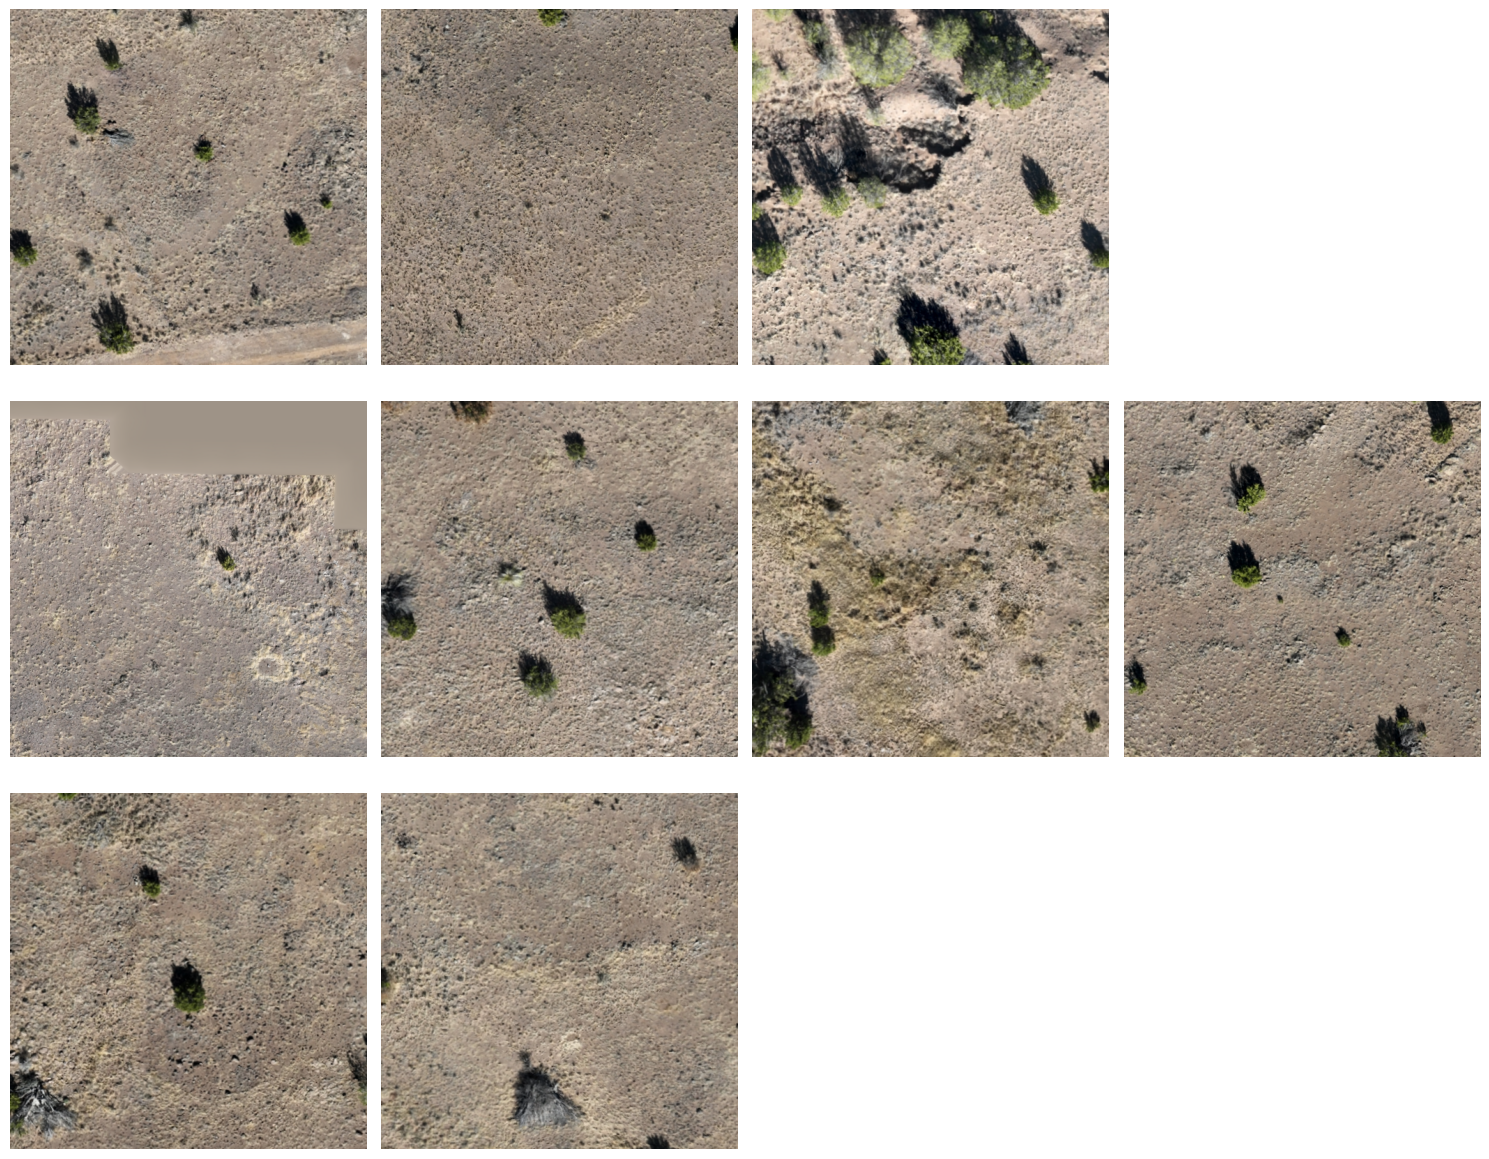

In [3]:
import random
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def get_random_samples(image_path, sample_size, num_samples):
    """
    Extract random samples from a large image.
    
    Parameters:
        image_path (str): Path to the orthophoto image.
        sample_size (int): Size of the square samples (e.g., 512 for 512x512).
        num_samples (int): Number of random samples to extract.

    Returns:
        List of numpy arrays representing the samples.
    """
    with rasterio.open(image_path) as src:
        width, height = src.width, src.height
        samples = []
        
        for _ in range(num_samples):
            # Random top-left corner coordinates for the sample
            x = random.randint(0, width - sample_size)
            y = random.randint(0, height - sample_size)
            
            # Read the sample from the image
            sample = src.read(
                window=rasterio.windows.Window(x, y, sample_size, sample_size)
            )
            samples.append(sample)
    
    return samples

def plot_samples(samples):
    """
    Plot a list of image samples for visualization.
    
    Parameters:
        samples (list): List of numpy arrays representing image samples.
    """
    num_samples = len(samples)
    cols = 4
    rows = (num_samples // cols) + (num_samples % cols > 0)
    
    plt.figure(figsize=(15, rows * 4))
    for i, sample in enumerate(samples):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.moveaxis(sample, 0, -1))  # Move channel axis for display
        plt.axis('off')
    plt.tight_layout()
    plt.show()


sample_size = 512
num_samples = 10

samples = get_random_samples(region_image_path, sample_size, num_samples)
plot_samples(samples)


In [12]:
import json
from shapely.geometry import shape
from ipyleaflet import (
    GeoData, GeoJSON, Map, Rectangle, TileLayer, 
    ScaleControl, GeomanDrawControl, LayersControl
)
from plant_search.verify_targets import get_image_sample_coordinates




def create_map(region_geojson, sample_boxes):
    """
    Create a map with rectangles showing the sample locations.

    Parameters:
        image_path (str): Path to the orthophoto image.
        sample_boxes (list): List of bounding box coordinates (top_left, bottom_right).
        crs (str): Coordinate reference system of the image.
    """
    with open(region_geojson, "r") as f:
        region_contour_data = json.load(f)
    region_geometry = shape(region_contour_data['features'][0]['geometry'])
    region_center = region_geometry.centroid
    
    
    # Initialize the map centered on the image
    m = Map(center=(region_center.y, region_center.x), 
            zoom=16, scroll_wheel_zoom=True,
            double_click_zoom=False,
            # crs=projections.EPSG4326,
        )

    # Add the region border to the map
    region_layer = GeoJSON(
        data=region_contour_data, 
        style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
        name=region_contour_data['name'])
    m.add(region_layer)

    # Add orthophoto overlay
    tile_layer = TileLayer(
        url="http://localhost:8000/{z}/{x}/{y}.png",
        min_zoom=15,
        max_zoom=22,
        show_loading=True,
        max_requests_per_tile=5,  # Adjust as needed
        name="Region Image")
    m.add(tile_layer)

    # # Add rectangles for each sample box
    # for box in sample_boxes:
    #     top_left, bottom_right = box
    #     rect = Rectangle(
    #         bounds=[[top_left[1], top_left[0]], [bottom_right[1], bottom_right[0]]],
    #         color="blue",
    #         fill_opacity=0.2,
    #         weight=2
    #     )
    #     m.add_layer(rect)

    samples_layer = GeoData(geo_dataframe = sample_boxes,
                   style={'color': 'blue', 'weight':2,
                          'fill': False, 'fillColor': 'red', 'fillOpacity': 0.2
                          },
                   hover_style={'color': 'red' , 'opacity': 1.0, 'fill': False},
                   name = 'Countries')
    m.add(samples_layer)

    draw_control = GeomanDrawControl()
    draw_control.circlemarker = {}
    draw_control.rotate = False
    # draw_control.cut = False
    draw_control.drag = False
    m.add(draw_control)

    # m.add(FullScreenControl(position='topleft'))
    m.add(LayersControl(position='topright'))
    m.add(ScaleControl(position='bottomleft'))

    return m

# Example Usage
# image_path = "path_to_large_image.tif"  # Replace with your image file path
sample_size = 512
num_samples = 10

sample_boxes_gpd = get_image_sample_coordinates(
    region_image_path, 
    sample_size, 
    num_samples, 
    region_contour_geojson
)

# Create the map
sample_map = create_map(region_contour_geojson, sample_boxes_gpd)
sample_map


Region polygon successfully loaded. Restricting samples to the polygon.


Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [6]:
sample_boxes_gpd

,geometry
0,"POLYGON ((-103.60261 30.24828, -103.60261 30.2..."
1,"POLYGON ((-103.59999 30.24873, -103.59999 30.2..."
2,"POLYGON ((-103.60321 30.24883, -103.60321 30.2..."
3,"POLYGON ((-103.60318 30.2496, -103.60318 30.24..."
4,"POLYGON ((-103.60084 30.24769, -103.60084 30.2..."
5,"POLYGON ((-103.59957 30.2475, -103.59957 30.24..."
6,"POLYGON ((-103.60115 30.24994, -103.60115 30.2..."
7,"POLYGON ((-103.60267 30.24868, -103.60267 30.2..."
8,"POLYGON ((-103.60189 30.24827, -103.60189 30.2..."
9,"POLYGON ((-103.59865 30.24977, -103.59865 30.2..."


## 3. Audit Target Results

In [67]:
from ipyleaflet import (
    Map, GeoJSON, LayersControl, ScaleControl, 
    FullScreenControl, GeomanDrawControl,
    TileLayer, LocalTileLayer, GeoData,
)
from ipyleaflet.projections import projections
from ipywidgets import Layout

from shapely.geometry import shape
from shapely.wkt import loads
import json
import geopandas as gpd

from ipyleaflet.projections import projections

def plot_route_on_image(region_geojson, depots_filename, micro_routes_filename, targets_plants_filename):

    # Get image data
    # image, transform, bounds, image_crs = load_image(orthophoto_path)

    with open(region_geojson, "r") as f:
        region_contour_data = json.load(f)
    region_geometry = shape(region_contour_data['features'][0]['geometry'])
    region_center = region_geometry.centroid

    with open(depots_filename, "r") as f:
        depot_data = json.load(f)

    with open(micro_routes_filename, "r") as f:
        micro_routes_data = json.load(f)

    with open(targets_plants_filename, "r") as f:
        targets_data = json.load(f)
    
    
    
    bboxes_gdf = gpd.read_file(targets_plants_filename) # Read in from file
    bboxes_gdf['bounding_box'] = bboxes_gdf['bounding_box'].apply(loads) # str to Polygon
    bboxes_gdf.set_geometry('bounding_box', inplace=True) # It is the primary geometry
    bboxes_gdf = bboxes_gdf.drop(columns=['region_outline_version', 'geometry']) # remove confusing cols
    bboxes_gdf = bboxes_gdf.set_crs(region_crs).to_crs(visualization_crs) # Needs CRS, then convert

    
    # bounding_boxes_gdf = gpd.GeoDataFrame(bboxes_gdf, geometry='geometry', crs=bboxes_gdf.crs)
    # bounding_boxes_geojson = bounding_boxes_gdf.to_json()

    # Set up the map
    m = Map(center=(region_center.y, region_center.x),
            zoom=16, scroll_wheel_zoom=True,
            double_click_zoom=False,
            layout=Layout(height="700px"),  # Set desired dimensions
            # crs=projections.EPSG4326
        )

    # Add orthophoto overlay
    tile_layer = TileLayer(
        url="http://localhost:8000/{z}/{x}/{y}.png",
        min_zoom=15,
        max_zoom=22,
        show_loading=True,
        max_requests_per_tile=5,  # Adjust as needed
        name="Region Image")
    m.add_layer(tile_layer)

    # Add the region border to the map
    region_layer = GeoJSON(
        data=region_contour_data, 
        style={'color': 'blue', 'fillOpacity': 0.05, 'weight': 2},
        name=region_contour_data['name'])
    m.add(region_layer)

    depot_points = GeoJSON(
        data=depot_data,
        style={'color': 'black', 'radius':10, 'fillColor': '#3366cc', 'opacity':0.5, 'weight':1.9, 'dashArray':'2', 'fillOpacity':0.6},
        hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        draggable=True,
        name=depot_data['name']
    )
    m.add(depot_points)

    routes_layer = GeoJSON(
        data=micro_routes_data, 
        style={'color': 'green', 'fillColor': 'green', 'opacity': 0.75, 'weight': 4},
        hover_style={'color': 'red' , 'opacity': 0.8, 'weight': 3},
        name=f'Micro Routes'
    )
    # m.add(routes_layer)

    targets_layer = GeoJSON(
        data=targets_data,
        style={'color': 'black', 'radius':6, 'fillColor': 'red', 'opacity':0.5, 'weight':1, 'fillOpacity':0.6},
        hover_style={'fillColor': 'red' , 'fillOpacity': 0.2},
        point_style={'radius': 3, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'blue', 'weight': 3},
        draggable=True,
        name=targets_data['name']
    )
    def on_click_target(event, feature, properties):
        # print(event)
        print(feature)
        print(properties)
        print(len(targets_data['features']))
        targets_data['features'] = [
            feature for feature in targets_data['features']
            if feature['properties']['target_id'] != properties['target_id']
        ]
        print(len(targets_data['features']))
        targets_layer.data = targets_data

    targets_layer.on_click(on_click_target)


    m.add(targets_layer)

    bboxes_layer = GeoData(geo_dataframe = bboxes_gdf,
                   style={'color': 'red', 'opacity':0.5, 'weight':1.9,
                          'fill': False, 'fillColor': 'red', 'fillOpacity': 0.2
                          },
                   hover_style={'color': 'red' , 'opacity': 1.0, 'fill': False},
                   name = 'Countries')
    # m.add(bboxes_layer)

    draw_control = GeomanDrawControl()
    draw_control.circlemarker = {}
    draw_control.rotate = False
    # draw_control.cut = False
    draw_control.drag = False
    m.add(draw_control)

    # m.add(FullScreenControl(position='topleft'))
    m.add(LayersControl(position='topright'))
    m.add(ScaleControl(position='bottomleft'))
    return m

m = plot_route_on_image(region_contour_geojson, depots_filename, micro_routes_filename, targets_plants_filename)
m

Map(center=[30.24893165719689, -103.6019209136208], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [68]:
with open(targets_plants_filename, "r") as f:
    targets_data = json.load(f)
print(targets_data['features'])    

[{'type': 'Feature', 'properties': {'bounding_box': 'POLYGON ((634323.7010862518 3347384.218589365, 634329.556744471 3347384.218589365, 634329.556744471 3347379.7992743305, 634323.7010862518 3347379.7992743305, 634323.7010862518 3347384.218589365))', 'target_id': '4e07e911-a98a-4beb-b937-0fafc2480978', 'region_outline_version': '2024-12-14', 'region_name': 'Brewster_57'}, 'geometry': {'type': 'Point', 'coordinates': [-103.603803918554, 30.2506277518032]}}, {'type': 'Feature', 'properties': {'bounding_box': 'POLYGON ((634442.8029647457 3347383.0032777307, 634444.4049844472 3347383.0032777307, 634444.4049844472 3347381.732724658, 634442.8029647457 3347381.732724658, 634442.8029647457 3347383.0032777307))', 'target_id': 'af68ffec-713e-4f94-a758-5422ca6ddd4c', 'region_outline_version': '2024-12-14', 'region_name': 'Brewster_57'}, 'geometry': {'type': 'Point', 'coordinates': [-103.60259102142537, 30.250617799616144]}}, {'type': 'Feature', 'properties': {'bounding_box': 'POLYGON ((634345.135